Задача из тренировочного контеста Яндекса «Машинное обучение».

Есть два алгоритма, которые генерируют случайные точки внутри единичного круга. Первый работает через полярные координаты, второй — методом отбраковки: бросает точку в квадрат и оставляет только если попала в круг. На выходе оба дают точки в круге, но распределены они по-разному.

Дано 100 наборов по 1000 точек, каждый набор целиком сгенерирован одним из двух алгоритмов. Нужно для каждого набора определить, каким именно. Порог для зачёта — 98 правильных ответов из 100.

В ноутбуке я разбираю оба генератора, смотрю на распределение точек и радиусов, вывожу решение аналитически, а затем решаю ту же задачу логистической регрессией и сравниваю результаты.

In [1]:
from random import uniform
from numpy import cos, sin, pi
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate1():
    a = uniform(0, 1)
    b = uniform(0, 1)
    return a * cos(2 * pi * b), a * sin(2 * pi * b)

Посмотрим на первый метод, но в векторном варианте, что значительно быстрее.
Для начала получим 2 массива с координатами точек. Метод подразумевает получение точек сразу в полярных координатах.
Зафиксировал сид для воспроизводимости результатов.

In [3]:
n = 1000
np.random.seed(42)
a = np.random.random(n)
b = np.random.random(n)
x = a * cos(2 * pi * b)
y = a * sin(2 * pi * b)

Наложим полученные точки на плоскость и визуально оценим распределение точек

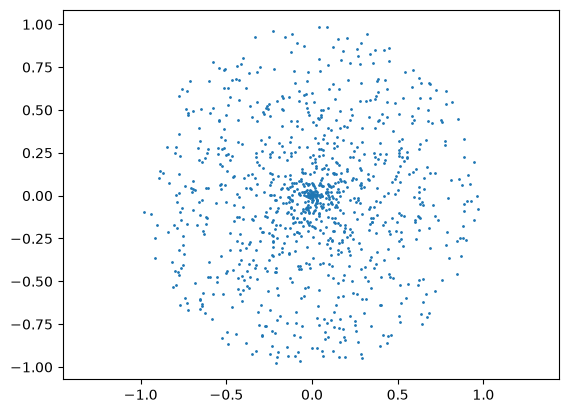

In [4]:
plt.scatter(x, y, s=1)
plt.axis('equal')
plt.show()

Очевидно, что точки распределяются неравномерно: видно смещение к центру круга. Это вызвано тем, что при таком методе на каждое "кольцо" одинаковой толщины распределено равномерное количество точек, но в связи с тем, что внешние кольца больше по площади, чем внутренние, внутри круга точки расположились значительно плотнее.
Если при подсчёте точек использовать вместо коэффициента a его корень, то можно добиться более равномерного распределения.
Посмотрим и на этот вариант.

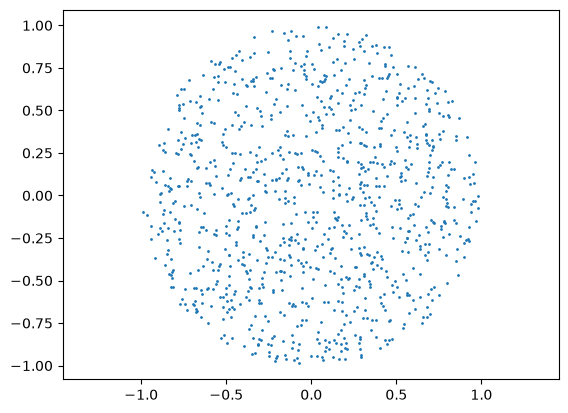

In [5]:
x = np.sqrt(a) * cos(2 * pi * b)
y = np.sqrt(a) * sin(2 * pi * b)
plt.scatter(x, y, s=1)
plt.axis('equal')
plt.show()

In [6]:
def generate2():
    while True:
        x = uniform(-1, 1)
        y = uniform(-1, 1)
        if x ** 2 + y ** 2 > 1:
            continue
        return x, y

Посмотрим на второй метод. Так же в векторном варианте. Это метод rejection sampling. Он даёт равномерное распределение точек по кругу по средствам получаения точек в единичном квадрате с последующим отбрасыванием точек, которые не входят в круг.

In [7]:
np.random.seed(42)
n = 1000
x = np.random.uniform(-1, 1, size=round(n/0.7))
y = np.random.uniform(-1, 1, size=round(n/0.7))
mask = x ** 2 + y ** 2 < 1
x, y = x[mask][:n], y[mask][:n]

Теперь посмотрим как распределены полученные точки.

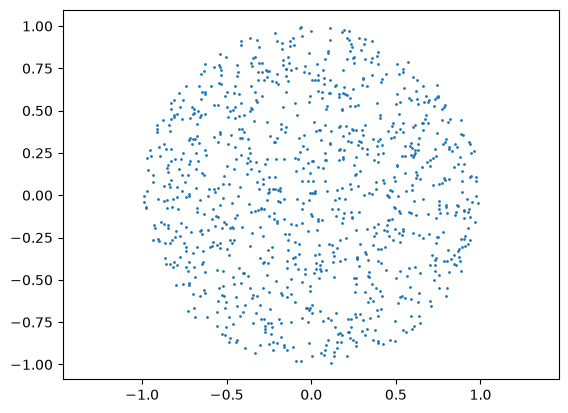

In [8]:
plt.scatter(x, y, s=1)
plt.axis('equal')
plt.show()

Видно, что точки распределяются равномерно, в отличие от метода 1. На этом отличие и будет основываться решение задачи. По сути перед нами стоит задача классификации: отнести объект к нужному классу.
Сведём двумерную задачу к одномерной тем, что будем рассматривать именно распределение радиусов в наборах точек.
В первом методе точки распределяются равномерно на весь радиус: в кольце 0 - 0.1 будет столько же точек, сколько и в кольцке 0.9-1, хотя площади у этих колец сильно отличаются. Во втором методе точки в круге распределяются исходя из соотношения площадей:
площадь круга с радиусом r / площадь всего круга = r^2
pi * r^2 / pi * 1^2 = r^2
Проверим как распределяются радиусы в обоих методах экспериментально.

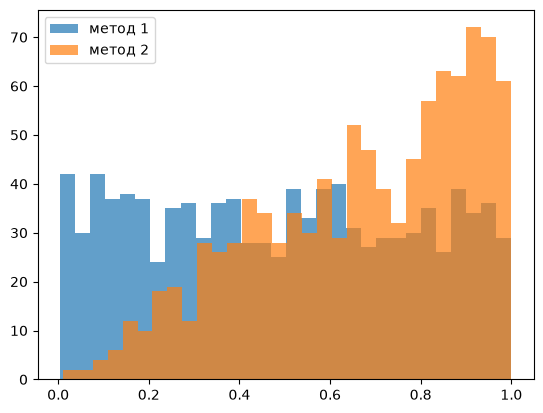

In [9]:
n = 1000
np.random.seed(42)
a = np.random.random(n)
b = np.random.random(n)
x1 = a * cos(2 * pi * b)
y1 = a * sin(2 * pi * b)
r1 = np.sqrt(x1**2 + y1**2)


n = 1000
x2 = np.random.uniform(-1, 1, size=round(n/0.7))
y2 = np.random.uniform(-1, 1, size=round(n/0.7))
mask = x2 ** 2 + y2 ** 2 < 1
x2, y2 = x2[mask][:1000], y2[mask][:1000]
r2 = np.sqrt(x2**2 + y2**2)

plt.hist(r1, bins=30, alpha=0.7, label='метод 1')
plt.hist(r2, bins=30, alpha=0.7, label='метод 2')
plt.legend()

Картина стала сильно яснее. По графику чётко видно, как распределяются радиусы в зависимости от выбранного метода. Отсюда можно сделать вывод: медианное значение радиусов разнится в зависимости от выбранного метода. Проверим гипотезу.

In [10]:
np.median(r1), np.median(r2)

(np.float64(0.4968073765468109), np.float64(0.7029483173661301))

Таким образом, решение задачи классификации сводится к определению медианы радиусов. Далее необходимо определить порог, разделяющий первый метод и второй.
Медиана - радиус внутри которого лежит половина точек, при первом методе половина точек лежит в радиусе 0.5, так как там действует равенство:
r = доля точек,
в случае второго метода работает другое равенство:
r ^ 2 = доля точек -> r = sqrt(доля точек). Так как мы решаем задачу для единичной окружности можно смело подставить r = 0.5 и тогда получим границу: sep = (r + sqrt(r)) / 2 ~ 0.6. Таким образом, если в наборе точек медианный радиус меньше 0.6, то относим его в методу 1, а если больше к методу 2.

Сформулируем решение задачи.

In [11]:
import sys
import numpy as np
res = []
for line in sys.stdin:
    if not line.strip():
        continue
    nums = np.array(line.split(), dtype=float)
    x = nums[::2]
    y = nums[1::2]
    rad_med = np.median(np.sqrt(x ** 2 + y ** 2))
    if rad_med < 0.6:
        cl = 1
    else:
        cl = 2
    res.append(cl)
print(*res, sep='\n')

По итогу работы было получено решение задачи из тренировочного контеста яндекс "Машинное обучение". Думаю, авторы подразумевали решение этой задачи именно методами машинного обучения, поэтому предлагаю рассмотреть решение данной задачи используя модель логистической регрессии.

Первым шагом создадим наборы данных для тренировки модели.

In [12]:
import random


n_dots = 1000
n_samples = 100

gen1 = []
gen2 = []
for s in range(n_samples):
    sample_gen1 = []
    sample_gen2 = []
    for d in range(n_dots):
        sample_gen1.append(generate1())
        sample_gen2.append(generate2())
    gen1.append(sample_gen1)
    gen2.append(sample_gen2)

g1_arr = np.array(gen1)
g2_arr = np.array(gen2)
g1_medians = np.median(np.sqrt(g1_arr[:, :, 0]**2 + g1_arr[:, :, 1]**2), axis=1)
g2_medians = np.median(np.sqrt(g2_arr[:, :, 0]**2 + g2_arr[:, :, 1]**2), axis=1)

Получили 2 массива с медианами радиусов - единственным признаком, полученные разными методами.
Далее разметим массивы, объединим их и разделим на трейн и тест.

In [15]:
zeros = np.zeros(100)
ones = np.ones(100)
X = np.concatenate((g1_medians, g2_medians), axis=0).reshape(-1, 1)
y = np.concatenate((zeros, ones), axis=0)

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

Импортируем нужную модель из библиотеки и обучим её на тренировочных данных.

In [16]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Модель обучена. Получим предсказания на тестовой выборке и получим все основные метрики одним методом.

In [19]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



Очевидно, модель обучена отлично, но это связано с тем, что задача очень проста.
Далее получим нужный нам вес и свободный член.

In [21]:
w = model.coef_[0][0]
bias = model.intercept_[0]
print(w, bias)

5.811443197621756 -3.482712654350109


Теперь сформируем решение задачи, используя веса обученной модели.

In [34]:
for line in sys.stdin:
    if not line:
        continue
    nums = np.array(line.split(), dtype=float)
    r = np.sqrt(nums[::2]**2 + nums[1::2]**2)
    z = w * np.median(r) + bias
    print(1 if z < 0 else 2)

Ради интереса можно сравнить порог признака, разделяющий классы, который мы получили аналитически с тем, что получился после обучения модели. Порог полученный ранее - mediana(r) = 0.6. Чтобы посмотреть какой порог мы имеем у обученной модели нужно понять в каком случае сигмоида равно ровно 0.5 - на стыке классов. Она равна 0.5 при Z = 0. Приравняем уравнение Z к нулю и выразим X.

In [35]:
# z = w * x + bias
# w * sep_model + bias == 0
sep_model = -bias / w
print(sep_model)

0.5992853299805728


Как видно, разница в 4-м знаке после запятой.

Выводы. 

Задача решилась не обучением модели, а пониманием того, как устроены данные. Два генератора отличаются только распределением радиуса, и это различие описывается простой формулой: r против r².

Важный момент, который был не сразу очевиден: объект классификации здесь — это набор точек, а не отдельная точка. Одну точку невозможно отнести к какому-либо методу, она могла быть получена и первым, и вторым. Информация о классе появляется только в совокупности, поэтому и признак должен быть таким, который не зависит от порядка точек внутри набора. Медиана радиуса подходит, координаты отдельных точек — нет.

Идеальные метрики на тесте говорят не о качестве модели, а о простоте задачи. При 1000 точек в наборе медианы двух классов вообще не пересекаются, так что сработал бы любой порог между ними. Интереснее задача стала бы при наборах поменьше — тогда медианы зашумились бы, классы начали перекрываться, и выбор границы стал бы иметь значение.

Итог: машинное обучение тут оказалось лишним. Знание о том, откуда взялись данные, дало решение проще и точнее, чем обучение на выборке.